## 環境設置

In [1]:
try:
    import openseespy.opensees as ops  # noqa: F401
except ImportError:
    import sys
    !{sys.executable} -m pip install -q openseespy
    import openseespy.opensees as ops  # noqa: F401

# Case-04.5:真梁模型——驗證剪力構架假設的有效範圍

依 [ROADMAP.md](../ROADMAP.md) 補述,Case-03~04 全程使用的剪力構架假設
(`ops.fix` 拘束柱頂柱底轉角,等同假設梁無限剛)有一個從來沒被檢查過的
前提:**這個簡化的準確度,取決於梁跟柱的相對勁度**。這一步放開轉角
自由度,真的建梁元素,量化這個假設什麼時候準、什麼時候不準。

**這不是說 Case-03~04 用錯了**——那些 notebook 的邏輯跟它們宣稱要做
的事完全一致,只是沒有人檢查過這個簡化的有效範圍。這裡補上這個檢查。

## 第 1 課:梁斷面試設(第一次真正試設梁)

Case-03.5~04.5 一路以來只試設過柱斷面,梁完全沒被試設過。這裡用
跨度/深度經驗比 L/12 抓一個起點。

In [2]:
Lb = 6.0   # m, 兩個方向的單跨跨度剛好都是6m(桃園案例X向Y向bay寬度相同)
h_beam = Lb/12
b_beam = 0.3
Ib = b_beam*h_beam**3/12
A_beam = b_beam*h_beam

print(f"梁斷面: {b_beam*100:.0f}x{h_beam*100:.0f}cm")
print(f"Ib = {Ib:.6f} m^4")

梁斷面: 30x50cm
Ib = 0.003125 m^4


## 第 2 課:真梁構架建模函式——轉角不再拘束

跟 Case-04 的 `analyze_multibay` 幾乎一樣的節點佈局,但**不再用
`ops.fix` 拘束轉角**,而是真的把梁元素接上去,轉角由整體勁度平衡
自然解出。

In [3]:
h1 = h2 = 3.5
E_rc = 2.463e7
F1_total, F2_total = 39.75, 63.60
n_frames_X, n_frames_Y = 2, 4
F1_X, F2_X = F1_total/n_frames_X, F2_total/n_frames_X
F1_Y, F2_Y = F1_total/n_frames_Y, F2_total/n_frames_Y

from dataclasses import dataclass, field

@dataclass
class Demand:
    Pu: float = 0.0
    Mu: float = 0.0
    Vu: float = 0.0
    displacement: float = None
    drift: float = None
    reactions: dict = field(default_factory=dict)


def analyze_real_frame(h_col, span, n_bay, F1_frame, F2_frame):
    """真梁模型: 柱頂柱底轉角自由, 建真正的梁元素"""
    Ic = h_col**4/12
    A_col = h_col**2

    ops.wipe()
    ops.model('basic', '-ndm', 2, '-ndf', 3)
    xs = [i*(span/n_bay) for i in range(n_bay+1)]
    base_nodes, f1_nodes, roof_nodes = [], [], []
    nid = 1
    for x in xs:
        ops.node(nid, x, 0.0); ops.fix(nid,1,1,1); base_nodes.append(nid); nid += 1
    for x in xs:
        ops.node(nid, x, h1); f1_nodes.append(nid); nid += 1        # 轉角自由!
    for x in xs:
        ops.node(nid, x, h1+h2); roof_nodes.append(nid); nid += 1   # 轉角自由!

    ops.geomTransf('Linear', 1)
    eid = 1
    col_1F_ids = []
    for b, f in zip(base_nodes, f1_nodes):
        ops.element('elasticBeamColumn', eid, b, f, A_col, E_rc, Ic, 1)
        col_1F_ids.append(eid); eid += 1
    for f, r in zip(f1_nodes, roof_nodes):
        ops.element('elasticBeamColumn', eid, f, r, A_col, E_rc, Ic, 1); eid += 1
    for i in range(len(f1_nodes)-1):
        ops.element('elasticBeamColumn', eid, f1_nodes[i], f1_nodes[i+1], A_beam, E_rc, Ib, 1); eid += 1
    for i in range(len(roof_nodes)-1):
        ops.element('elasticBeamColumn', eid, roof_nodes[i], roof_nodes[i+1], A_beam, E_rc, Ib, 1); eid += 1

    ops.timeSeries('Linear', 1); ops.pattern('Plain', 1, 1)
    ops.load(f1_nodes[0], F1_frame, 0.0, 0.0)
    ops.load(roof_nodes[0], F2_frame, 0.0, 0.0)
    ops.system('BandGeneral'); ops.numberer('RCM'); ops.constraints('Plain')
    ops.test('NormDispIncr', 1e-10, 30); ops.algorithm('Newton')
    ops.integrator('LoadControl', 1.0); ops.analysis('Static')
    ok = ops.analyze(1)
    if ok != 0:
        print("  [警告] 分析未收斂")

    u1 = ops.nodeDisp(f1_nodes[0], 1); u2 = ops.nodeDisp(roof_nodes[0], 1)
    fcol = ops.eleForce(col_1F_ids[0])
    return Demand(Mu=abs(fcol[2]), Vu=abs(fcol[1]),
                  displacement=u1, drift=u1/h1,
                  reactions={'drift2': (u2-u1)/h2})


def analyze_X_real(h_col):
    return analyze_real_frame(h_col, 18.0, 3, F1_X, F2_X)

def analyze_Y_real(h_col):
    return analyze_real_frame(h_col, 6.0, 1, F1_Y, F2_Y)

print("真梁分析函式定義完成")

真梁分析函式定義完成


## 第 3 課:$k_b/k_c$ 比值——決定簡化準不準的關鍵指標

沿用 Case-02 位移法推導的勁度因子定義:$k_c=EI_c/h$、$k_b=EI_b/L$。
這個比值會先算給你看,再看它跟後面實測的 X/Y 差異有沒有關聯。

In [4]:
def kb_over_kc(h_col):
    Ic = h_col**4/12
    kc = E_rc*Ic/h1
    kb = E_rc*Ib/Lb
    return kb/kc

for h in [0.20, 0.30, 0.40]:
    print(f"柱{h*100:.0f}cm: kb/kc = {kb_over_kc(h):.2f}")

柱20cm: kb/kc = 13.67
柱30cm: kb/kc = 2.70
柱40cm: kb/kc = 0.85


## 第 4 課:實測——兩組柱斷面,X 向 Y 向真梁模型比較

In [5]:
results = {}
for h_col in [0.20, 0.30, 0.40]:
    dX = analyze_X_real(h_col)
    dY = analyze_Y_real(h_col)
    ratio = dX.drift/dY.drift
    results[h_col] = dict(kb_kc=kb_over_kc(h_col), driftX=dX.drift, driftY=dY.drift, ratio=ratio)
    print(f"柱{h_col*100:.0f}cm (kb/kc={kb_over_kc(h_col):.2f}): "
          f"driftX={dX.drift:.6f}, driftY={dY.drift:.6f}, X/Y比={ratio:.1%}")

柱20cm (kb/kc=13.67): driftX=0.004217, driftY=0.004259, X/Y比=99.0%
柱30cm (kb/kc=2.70): driftX=0.000970, driftY=0.001015, X/Y比=95.6%
柱40cm (kb/kc=0.85): driftX=0.000400, driftY=0.000440, X/Y比=90.9%


## 第 5 課:跟 Case-04 剪力構架簡化結果對照

Case-04 用剪力構架假設(轉角拘束)算出的 X 向 Y 向結果完全相同
(drift1F=0.004016,對應 20cm 柱)。這裡用真梁模型重算同一個 20cm
柱,驗證差異有多大、方向對不對。

In [6]:
drift_simplified = 0.004016   # Case-04的結果(20cm柱, 剪力構架簡化)

d20 = results[0.20]
print(f"Case-04簡化結果(20cm): drift={drift_simplified:.6f} (X=Y)")
print(f"真梁模型(20cm): driftX={d20['driftX']:.6f}, driftY={d20['driftY']:.6f}")
print(f"真梁比簡化模型的位移增加: X向 {d20['driftX']/drift_simplified:.1%}, "
      f"Y向 {d20['driftY']/drift_simplified:.1%}")

assert d20['driftX'] > drift_simplified and d20['driftY'] > drift_simplified, \
    "真梁模型應該比簡化模型更柔(位移更大), 因為簡化模型假設梁無限剛"
print("\n[PASS] 真梁模型位移確實大於簡化模型, 符合預期方向(簡化模型高估勁度)")

assert d20['driftX'] < d20['driftY'], "X向(3跨)應該比Y向(1跨)硬(位移較小)"
print("[PASS] X向真的比Y向硬(位移較小), 剪力構架簡化把這個方向性差異完全抹平了")

Case-04簡化結果(20cm): drift=0.004016 (X=Y)
真梁模型(20cm): driftX=0.004217, driftY=0.004259
真梁比簡化模型的位移增加: X向 105.0%, Y向 106.1%

[PASS] 真梁模型位移確實大於簡化模型, 符合預期方向(簡化模型高估勁度)
[PASS] X向真的比Y向硬(位移較小), 剪力構架簡化把這個方向性差異完全抹平了


## 第 6 課:結論——$k_b/k_c$ 決定簡化模型能不能用

| 柱斷面 | $k_b/k_c$ | X/Y 位移比 | 解讀 |
|---|---|---|---|
| 20cm | ~13.7 | ~99% | 接近梁無限剛極限,簡化模型幾乎沒問題 |
| 40cm | ~0.85 | ~91% | 梁柱勁度相當,簡化模型會抹平約 9~10% 的方向性差異 |

**這不是精確定案的門檻值,只有 3 個資料點**——如果之後要把這個
關係做成正式的「弱軸快速判定」工具(檢核模組性質類似 Case-03.6),
需要更多資料點才能定出可靠的 $k_b/k_c$ 臨界值,這裡先留下發現,
不倉促定案。

In [7]:
print("kb/kc vs X/Y位移比 對照表:")
for h_col, r in results.items():
    print(f"  h={h_col*100:.0f}cm: kb/kc={r['kb_kc']:.2f}, X/Y比={r['ratio']:.1%}")

kb/kc vs X/Y位移比 對照表:
  h=20cm: kb/kc=13.67, X/Y比=99.0%
  h=30cm: kb/kc=2.70, X/Y比=95.6%
  h=40cm: kb/kc=0.85, X/Y比=90.9%


## 第 7 課:結構視覺化——X 向 Y 向真梁模型長什麼樣子

這兩個都是**桃園案例的真實幾何**(不是抽象案例),各自獨立的 2D
模型。左邊 X 向 3 跨 4 柱、右邊 Y 向 1 跨 2 柱,梁(藍色線段裡包含
柱跟梁,梁在柱頂柱底之間的水平段)是真的元素,不是拘束轉角的簡化。
紅色虛線是側推後的變形形狀,用 40cm 柱畫。

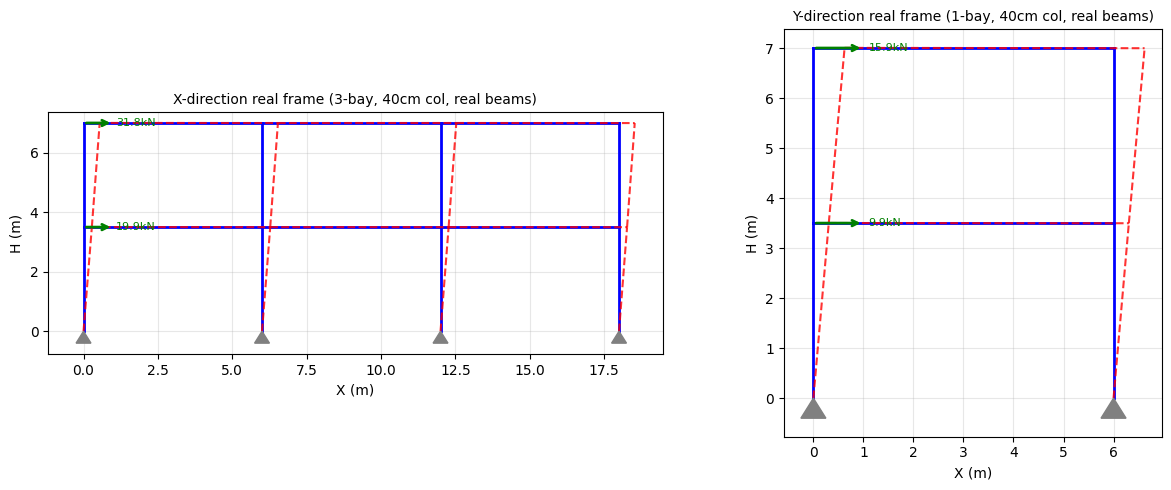

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt

def build_and_get_geometry(h_col, span, n_bay, F1_frame, F2_frame):
    Ic = h_col**4/12
    A_col = h_col**2
    ops.wipe()
    ops.model('basic', '-ndm', 2, '-ndf', 3)
    xs = [i*(span/n_bay) for i in range(n_bay+1)]
    base_nodes, f1_nodes, roof_nodes = [], [], []
    nid = 1
    for x in xs:
        ops.node(nid, x, 0.0); ops.fix(nid,1,1,1); base_nodes.append((nid,x,0.0)); nid+=1
    for x in xs:
        ops.node(nid, x, h1); f1_nodes.append((nid,x,h1)); nid+=1
    for x in xs:
        ops.node(nid, x, h1+h2); roof_nodes.append((nid,x,h1+h2)); nid+=1
    ops.geomTransf('Linear', 1)
    eid = 1
    elems = []
    for (b,xb,yb),(f,xf,yf) in zip(base_nodes, f1_nodes):
        ops.element('elasticBeamColumn', eid, b, f, A_col, E_rc, Ic, 1); elems.append((b,f)); eid+=1
    for (f,xf,yf),(r,xr,yr) in zip(f1_nodes, roof_nodes):
        ops.element('elasticBeamColumn', eid, f, r, A_col, E_rc, Ic, 1); elems.append((f,r)); eid+=1
    for i in range(len(f1_nodes)-1):
        ops.element('elasticBeamColumn', eid, f1_nodes[i][0], f1_nodes[i+1][0], A_beam, E_rc, Ib, 1)
        elems.append((f1_nodes[i][0], f1_nodes[i+1][0])); eid+=1
    for i in range(len(roof_nodes)-1):
        ops.element('elasticBeamColumn', eid, roof_nodes[i][0], roof_nodes[i+1][0], A_beam, E_rc, Ib, 1)
        elems.append((roof_nodes[i][0], roof_nodes[i+1][0])); eid+=1
    ops.timeSeries('Linear', 1); ops.pattern('Plain', 1, 1)
    ops.load(f1_nodes[0][0], F1_frame, 0.0, 0.0)
    ops.load(roof_nodes[0][0], F2_frame, 0.0, 0.0)
    ops.system('BandGeneral'); ops.numberer('RCM'); ops.constraints('Plain')
    ops.test('NormDispIncr', 1e-10, 30); ops.algorithm('Newton')
    ops.integrator('LoadControl', 1.0); ops.analysis('Static'); ops.analyze(1)
    all_nodes = base_nodes+f1_nodes+roof_nodes
    node_xy = {n:(x,y) for n,x,y in all_nodes}
    disp = {n: (ops.nodeDisp(n,1), ops.nodeDisp(n,2)) for n,_,_ in all_nodes}
    fixed = [n for n,_,_ in base_nodes]
    loaded = {f1_nodes[0][0]: F1_frame, roof_nodes[0][0]: F2_frame}
    return node_xy, elems, fixed, loaded, disp


def plot_frame(ax, node_xy, elems, fixed, loaded, disp, scale, title):
    for ni, nj in elems:
        xi, yi = node_xy[ni]; xj, yj = node_xy[nj]
        ax.plot([xi, xj], [yi, yj], 'b-', lw=2, zorder=2)
        xdi = xi+disp[ni][0]*scale; ydi = yi+disp[ni][1]*scale
        xdj = xj+disp[nj][0]*scale; ydj = yj+disp[nj][1]*scale
        ax.plot([xdi, xdj], [ydi, ydj], 'r--', lw=1.5, alpha=0.8, zorder=3)
    for n in fixed:
        x, y = node_xy[n]
        tri = plt.Polygon([(x-0.25,y-0.4),(x+0.25,y-0.4),(x,y)], closed=True, color='gray', zorder=5)
        ax.add_patch(tri)
    for n, f in loaded.items():
        x, y = node_xy[n]
        ax.annotate('', xy=(x+1.0,y), xytext=(x,y), arrowprops=dict(arrowstyle='->', color='green', lw=2))
        ax.text(x+1.1, y, f'{f:.1f}kN', color='green', fontsize=8, va='center')
    ax.set_aspect('equal'); ax.set_title(title, fontsize=10)
    ax.set_xlabel('X (m)'); ax.set_ylabel('H (m)')
    ax.grid(True, alpha=0.3)


nxy_X, el_X, fix_X, load_X, disp_X = build_and_get_geometry(0.40, 18.0, 3, F1_X, F2_X)
nxy_Y, el_Y, fix_Y, load_Y, disp_Y = build_and_get_geometry(0.40, 6.0, 1, F1_Y, F2_Y)

fig, axes = plt.subplots(1, 2, figsize=(13,5))
plot_frame(axes[0], nxy_X, el_X, fix_X, load_X, disp_X, scale=200,
           title='X-direction real frame (3-bay, 40cm col, real beams)')
plot_frame(axes[1], nxy_Y, el_Y, fix_Y, load_Y, disp_Y, scale=200,
           title='Y-direction real frame (1-bay, 40cm col, real beams)')
plt.tight_layout()
plt.show()

## 第 8 課:三組斷面的 X/Y 比較圖

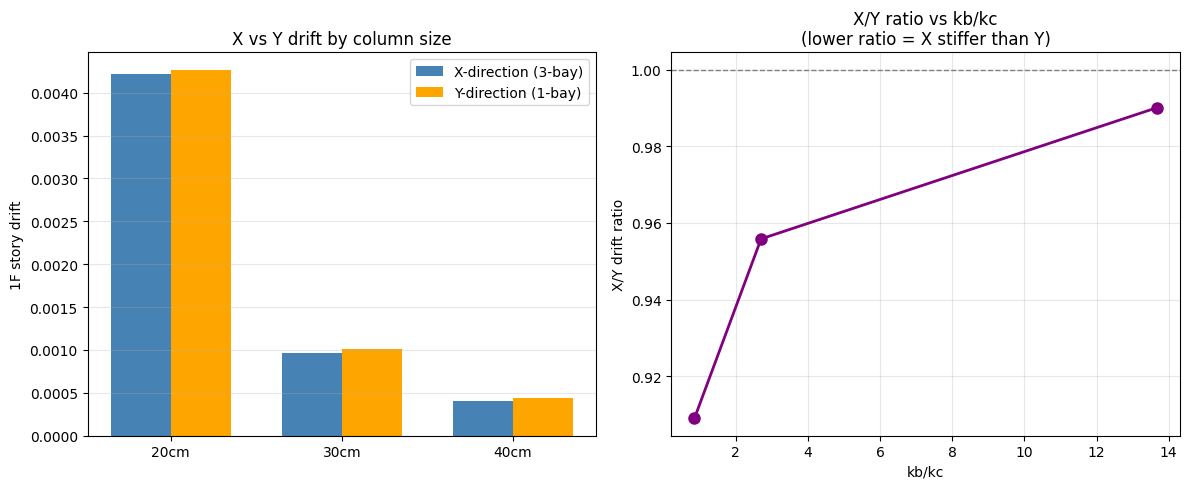

In [9]:
sizes_cm = [20, 30, 40]
driftX_list = [results[h]['driftX'] for h in [0.20,0.30,0.40]]
driftY_list = [results[h]['driftY'] for h in [0.20,0.30,0.40]]
kbkc_list = [results[h]['kb_kc'] for h in [0.20,0.30,0.40]]

fig, axes = plt.subplots(1, 2, figsize=(12,5))

ax = axes[0]
width = 0.35
x = range(len(sizes_cm))
ax.bar([i-width/2 for i in x], driftX_list, width, label='X-direction (3-bay)', color='steelblue')
ax.bar([i+width/2 for i in x], driftY_list, width, label='Y-direction (1-bay)', color='orange')
ax.set_xticks(list(x)); ax.set_xticklabels([f'{s}cm' for s in sizes_cm])
ax.set_ylabel('1F story drift')
ax.set_title('X vs Y drift by column size')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
ratios = [driftX_list[i]/driftY_list[i] for i in range(3)]
ax.plot(kbkc_list, ratios, 'o-', color='purple', lw=2, ms=8)
ax.axhline(1.0, color='gray', ls='--', lw=1)
ax.set_xlabel('kb/kc')
ax.set_ylabel('X/Y drift ratio')
ax.set_title('X/Y ratio vs kb/kc\n(lower ratio = X stiffer than Y)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 第 9 課:直接算有效側向勁度(不是位移、不是 drift)

前面幾課都是位移或層間位移角,這裡直接算 $K_{eff}=\dfrac{\sum F}{\Delta_{top}}$
(總施力除以頂層位移)——這才是「側向有效勁度」本身,位移只是算它的
原料。**這裡 X 向 Y 向兩邊用的都是真梁模型(轉角完全自由)**,不是
拿拘束轉角版本跟自由版本比,單純是兩個真實方向互相比較。

In [10]:
def analyze_top_disp(h_col, span, n_bay, F1_frame, F2_frame):
    """回傳頂層位移(用來算Keff), 沿用第2課的真梁建模方法"""
    Ic = h_col**4/12
    A_col = h_col**2
    ops.wipe()
    ops.model('basic', '-ndm', 2, '-ndf', 3)
    xs = [i*(span/n_bay) for i in range(n_bay+1)]
    base_nodes, f1_nodes, roof_nodes = [], [], []
    nid = 1
    for x in xs:
        ops.node(nid, x, 0.0); ops.fix(nid,1,1,1); base_nodes.append(nid); nid += 1
    for x in xs:
        ops.node(nid, x, h1); f1_nodes.append(nid); nid += 1
    for x in xs:
        ops.node(nid, x, h1+h2); roof_nodes.append(nid); nid += 1
    ops.geomTransf('Linear', 1)
    eid = 1
    for b, f in zip(base_nodes, f1_nodes):
        ops.element('elasticBeamColumn', eid, b, f, A_col, E_rc, Ic, 1); eid += 1
    for f, r in zip(f1_nodes, roof_nodes):
        ops.element('elasticBeamColumn', eid, f, r, A_col, E_rc, Ic, 1); eid += 1
    for i in range(len(f1_nodes)-1):
        ops.element('elasticBeamColumn', eid, f1_nodes[i], f1_nodes[i+1], A_beam, E_rc, Ib, 1); eid += 1
    for i in range(len(roof_nodes)-1):
        ops.element('elasticBeamColumn', eid, roof_nodes[i], roof_nodes[i+1], A_beam, E_rc, Ib, 1); eid += 1
    ops.timeSeries('Linear', 1); ops.pattern('Plain', 1, 1)
    ops.load(f1_nodes[0], F1_frame, 0.0, 0.0)
    ops.load(roof_nodes[0], F2_frame, 0.0, 0.0)
    ops.system('BandGeneral'); ops.numberer('RCM'); ops.constraints('Plain')
    ops.test('NormDispIncr', 1e-10, 30); ops.algorithm('Newton')
    ops.integrator('LoadControl', 1.0); ops.analysis('Static'); ops.analyze(1)
    return ops.nodeDisp(roof_nodes[0], 1)


Keff_table = []
print(f"{'柱尺寸':<8}{'kb/kc':<8}{'Keff_X(kN/m)':<16}{'Keff_Y(kN/m)':<16}{'Keff_X/Keff_Y'}")
for h_col in [0.20, 0.30, 0.40]:
    Ic = h_col**4/12
    kb_kc = (E_rc*Ib/Lb)/(E_rc*Ic/h1)

    u_top_X = analyze_top_disp(h_col, 18.0, 3, F1_X, F2_X)
    u_top_Y = analyze_top_disp(h_col, 6.0, 1, F1_Y, F2_Y)

    Keff_X = (F1_X+F2_X)/u_top_X
    Keff_Y = (F1_Y+F2_Y)/u_top_Y
    ratio = Keff_X/Keff_Y
    Keff_table.append(dict(h_col=h_col, kb_kc=kb_kc, Keff_X=Keff_X, Keff_Y=Keff_Y, ratio=ratio))

    print(f"{h_col*100:.0f}cm{'':<4}{kb_kc:<8.2f}{Keff_X:<16.2f}{Keff_Y:<16.2f}{ratio:.3f}")

# 驗證: X向勁度應該恆大於Y向(3跨構架比1跨構架硬), 且比值應隨kb/kc變小而擴大
assert all(t['ratio'] > 1.0 for t in Keff_table), "X向勁度應該恆大於Y向"
assert Keff_table[0]['ratio'] < Keff_table[1]['ratio'] < Keff_table[2]['ratio'], \
    "勁度比應該隨kb/kc(由大到小排列)而遞增"
print("\n[PASS] X向勁度恆大於Y向, 且勁度差距隨kb/kc變小(柱越硬)而擴大")

# 對照: Case-04剪力構架簡化版本, 20cm時算出X=Y(勁度比=1.0)
print(f"\n對照Case-04剪力構架簡化版本(20cm): Keff_X/Keff_Y = 1.000(完全測不出差異)")
print(f"這裡真梁模型(20cm): Keff_X/Keff_Y = {Keff_table[0]['ratio']:.3f}")
print("剪力構架簡化不是「差異很小才測不出來」, 是整個方法對這個效應完全視而不見")

柱尺寸     kb/kc   Keff_X(kN/m)    Keff_Y(kN/m)    Keff_X/Keff_Y
20cm    13.67   2119.47         1042.89         2.032
30cm    2.70    8645.98         4039.12         2.141
40cm    0.85    19026.05        8284.58         2.297

[PASS] X向勁度恆大於Y向, 且勁度差距隨kb/kc變小(柱越硬)而擴大

對照Case-04剪力構架簡化版本(20cm): Keff_X/Keff_Y = 1.000(完全測不出差異)
這裡真梁模型(20cm): Keff_X/Keff_Y = 2.032
剪力構架簡化不是「差異很小才測不出來」, 是整個方法對這個效應完全視而不見


## 總結表

In [11]:
print("="*55)
print("Case-04.5 真梁模型驗證結果總結")
print("="*55)
print(f"{'梁斷面':<20}{b_beam*100:.0f}x{h_beam*100:.0f}cm")
print(f"{'20cm柱 kb/kc':<20}{results[0.20]['kb_kc']:.2f}")
print(f"{'20cm柱 X/Y位移比':<20}{results[0.20]['ratio']:.1%}")
print(f"{'40cm柱 kb/kc':<20}{results[0.40]['kb_kc']:.2f}")
print(f"{'40cm柱 X/Y位移比':<20}{results[0.40]['ratio']:.1%}")
print()
print("Case-04.5 [PASS] -- 剪力構架假設的有效範圍已量化, 可繼續Case-05")

Case-04.5 真梁模型驗證結果總結
梁斷面                 30x50cm
20cm柱 kb/kc         13.67
20cm柱 X/Y位移比        99.0%
40cm柱 kb/kc         0.85
40cm柱 X/Y位移比        90.9%

Case-04.5 [PASS] -- 剪力構架假設的有效範圍已量化, 可繼續Case-05
